# 04b - Extended Visualizations

This notebook provides deeper insights into model performance by comparing all evaluated models (Classical, Base ML, and Extended ML) and looking into feature importance and residual analysis.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style('whitegrid')
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS_DIR = BASE_DIR / 'artifacts'

# Load all metric summaries
classical = pd.read_csv(ARTIFACTS_DIR / 'classical_metrics_summary.csv')
ml_base = pd.read_csv(ARTIFACTS_DIR / 'ml_metrics_summary.csv')
ml_extended = pd.read_csv(ARTIFACTS_DIR / 'ml_extended_metrics_summary.csv')

all_summary = pd.concat([classical, ml_base, ml_extended], ignore_index=True)
all_summary = all_summary.drop_duplicates(subset=['target', 'model']).sort_values(['target', 'RMSE'])
all_summary.to_csv(ARTIFACTS_DIR / 'combined_all_metrics.csv', index=False)
all_summary.head(10)

,target,model,MAE,MSE,RMSE,MAPE
0,daily_orders,ARIMA,9.797719,152.641481,12.290706,7.245702
1,daily_orders,SARIMA,9.862489,152.757520,12.293453,7.307824
2,daily_orders,Holt,9.764759,153.552253,12.330644,7.270014
3,daily_orders,ETS,9.998952,157.625119,12.484049,7.447087
16,daily_orders,Lasso,10.098949,161.505537,12.580005,7.626157
17,daily_orders,Ridge,10.127362,163.392477,12.647709,7.654068
12,daily_orders,LinearRegression,10.127928,163.495018,12.651407,7.654634
19,daily_orders,RandomForest,10.377590,171.071527,12.998611,7.893480
20,daily_orders,LightGBM,10.355825,176.877385,13.158894,7.737705
13,daily_orders,XGBoost,11.333072,198.538751,13.980754,8.670421


C:\Users\RITIK SINHA\AppData\Local\Temp\ipykernel_18872\1877401673.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x='model', y=metric, palette='viridis')


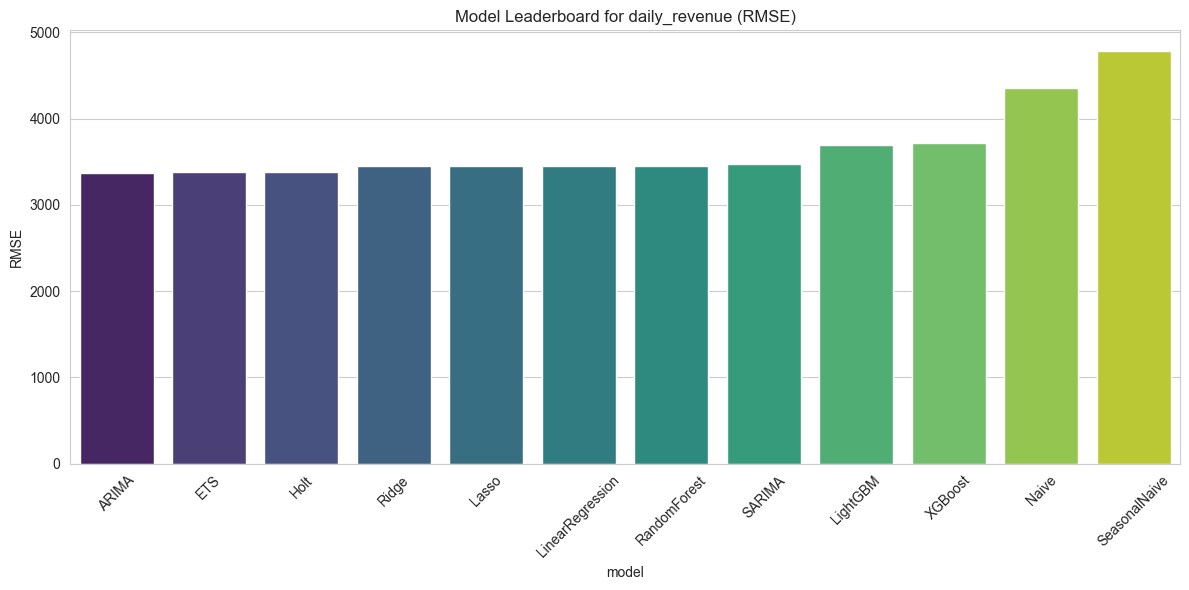

C:\Users\RITIK SINHA\AppData\Local\Temp\ipykernel_18872\1877401673.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x='model', y=metric, palette='viridis')


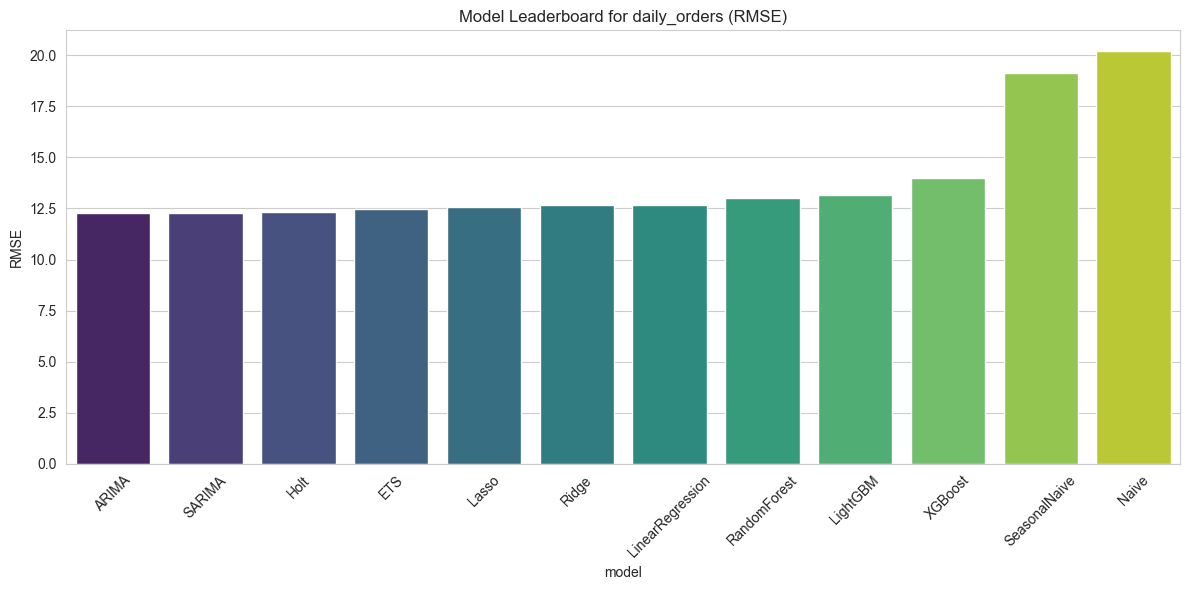

In [2]:
def plot_leaderboard(df, target_name, metric='RMSE'):
    subset = df[df['target'] == target_name].sort_values(metric)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=subset, x='model', y=metric, palette='viridis')
    plt.title(f'Model Leaderboard for {target_name} ({metric})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'04b_leaderboard_{target_name}.png')
    plt.show()

plot_leaderboard(all_summary, 'daily_revenue')
plot_leaderboard(all_summary, 'daily_orders')

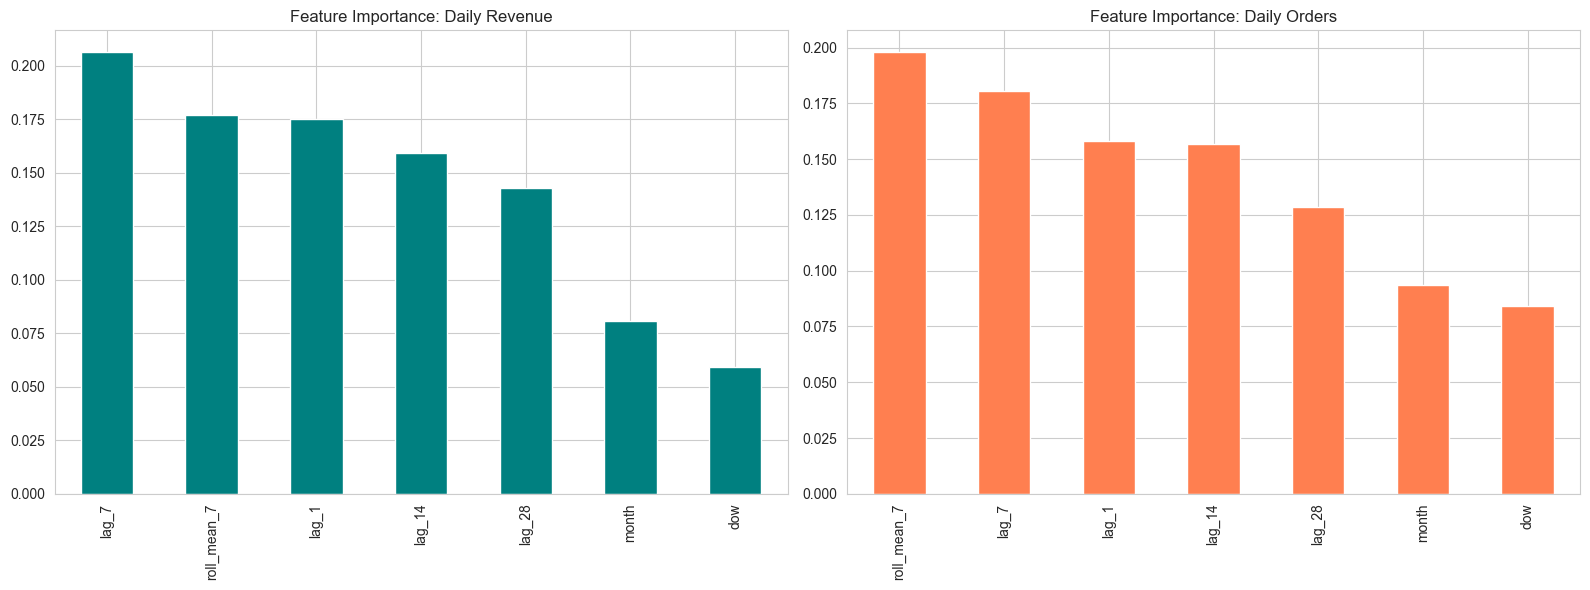

In [3]:
from sklearn.ensemble import RandomForestRegressor

def get_feature_importance(target_name):
    df = pd.read_csv(ARTIFACTS_DIR / 'daily_series.csv', parse_dates=['date']).set_index('date')
    series = df[target_name].astype(float)
    
    # Simple manual supervised frame creation for importance check
    d = pd.DataFrame({'y': series})
    for lag in (1, 7, 14, 28): d[f'lag_{lag}'] = d['y'].shift(lag)
    d['roll_mean_7'] = d['y'].shift(1).rolling(7).mean()
    d['dow'] = d.index.dayofweek
    d['month'] = d.index.month
    d = d.dropna()
    
    X = d.drop(columns=['y'])
    y = d['y']
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    return importances

imp_revenue = get_feature_importance('daily_revenue')
imp_orders = get_feature_importance('daily_orders')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
imp_revenue.plot(kind='bar', ax=ax1, color='teal')
ax1.set_title('Feature Importance: Daily Revenue')
imp_orders.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Feature Importance: Daily Orders')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04b_feature_importance.png')
plt.show()

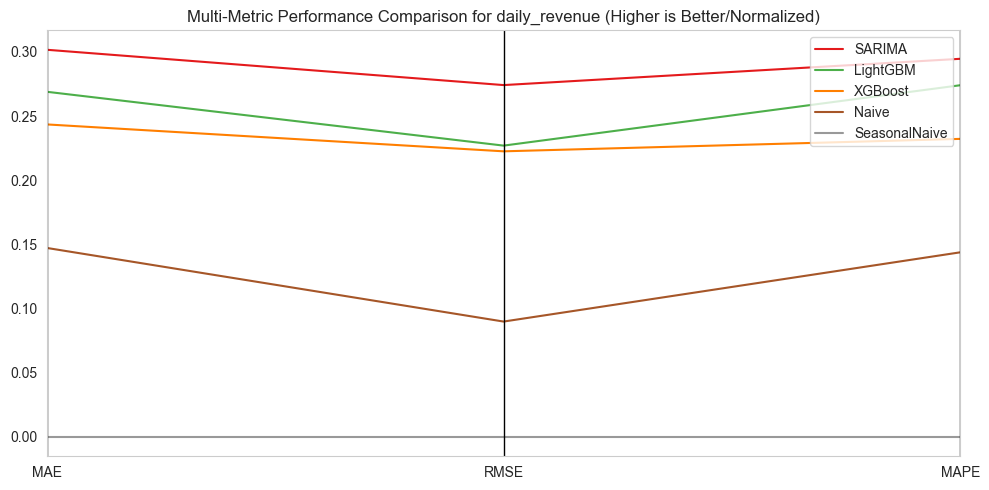

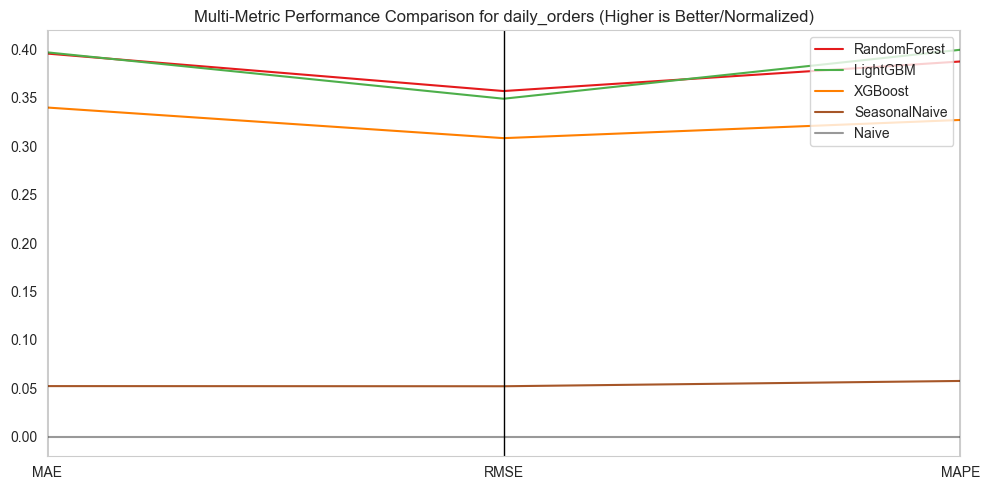

In [4]:
def plot_metric_radar(df, target_name):
    metrics = ['MAE', 'RMSE', 'MAPE']
    subset = df[df['target'] == target_name].copy()
    
    # Normalize metrics for visualization (lower is better, so we use 1/metric or similar, or just scale)
    for m in metrics:
        subset[m] = 1 - (subset[m] / subset[m].max())
        
    # Select top 5 models
    top_models = subset.nsmallest(5, 'RMSE')['model'].tolist()
    
    # Custom Radar Implementation (Simplified Parallel Coordinates)
    plt.figure(figsize=(10, 5))
    pd.plotting.parallel_coordinates(subset[subset['model'].isin(top_models)], 'model', cols=metrics, colormap='Set1')
    plt.title(f'Multi-Metric Performance Comparison for {target_name} (Higher is Better/Normalized)')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'04b_radar_performance_{target_name}.png')
    plt.show()

plot_metric_radar(all_summary, 'daily_revenue')
plot_metric_radar(all_summary, 'daily_orders')